<a href="https://colab.research.google.com/github/cabamarcos/CIFAR10_CNN/blob/main/muinar06_act2_individual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 61s 0us/step


In [3]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [4]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [5]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## Análisis exploratorio de los datos

Primero vamos a ver el tamaño de los datasets y las imágenes

In [6]:
print("Tamaño de una imagen (altura, anchura, canales):", x_train[0].shape)

print("Forma del conjunto de entrenamiento:", x_train.shape)
print("Forma del conjunto de validación:", x_valid.shape)
print("Forma del conjunto de test:", x_test.shape)


Tamaño de una imagen (altura, anchura, canales): (32, 32, 3)
Forma del conjunto de entrenamiento: (40000, 32, 32, 3)
Forma del conjunto de validación: (10000, 32, 32, 3)
Forma del conjunto de test: (10000, 32, 32, 3)


En la siguiente celda vamos a ver la primera imágen de cada clase del dataset

<ipython-input-7-38e3afeaa2fe>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[i])


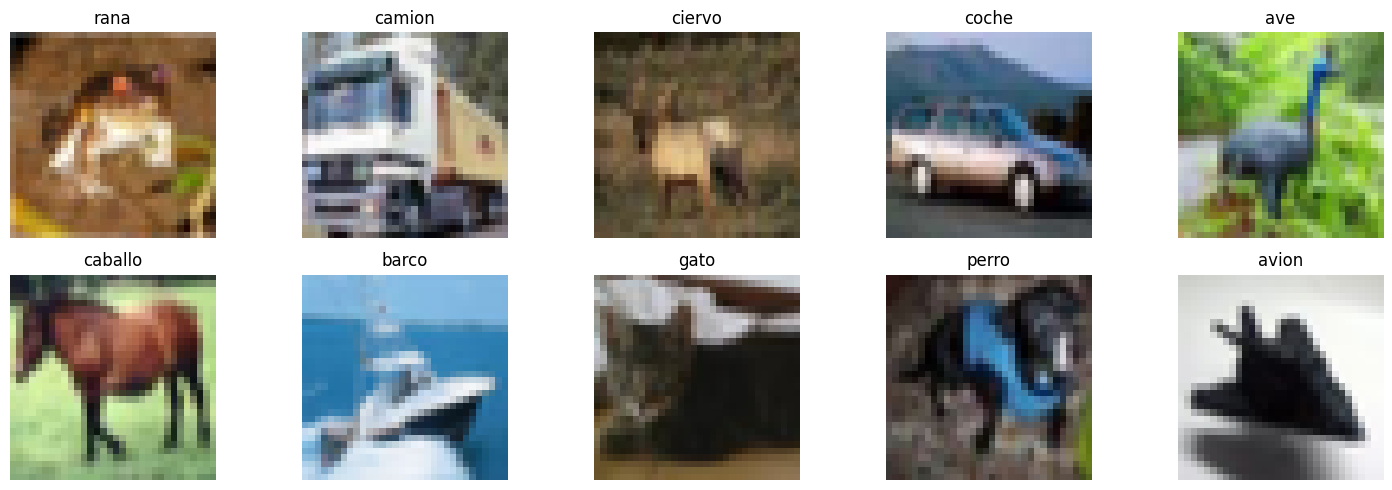

In [7]:
samples = {}
for i in range(len(y_train)):
    label = int(y_train[i])
    if label not in samples:
        samples[label] = x_train[i]
    if len(samples) == 10:
        break

plt.figure(figsize=(15, 5))
for idx, (label, image) in enumerate(samples.items()):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)
    plt.title(MAP_ELEMENTS[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

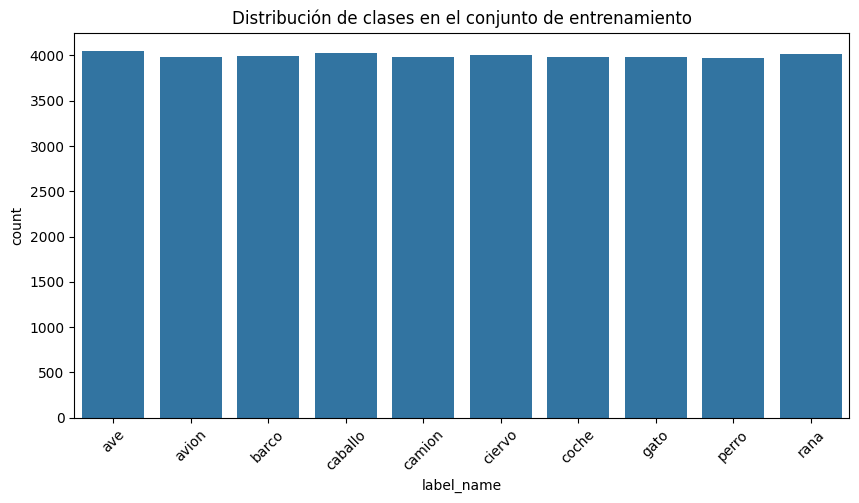

In [8]:
df_labels = pd.DataFrame(y_train, columns=['label'])
df_labels['label_name'] = df_labels['label'].map(MAP_ELEMENTS)

# Gráfico de conteo
plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=df_labels, order=sorted(MAP_ELEMENTS.values()))
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xticks(rotation=45)
plt.show()


Como podemos ver, el dataset está muy balanceado, por lo que no habrá que tomar ninguna medida respecto a esto

## Modelos

### Perceptrón multicapa

Ya sabemos que un perceptrón multicapa no va a poder tener muy buenos resultados en un dataset con imágenes algo complejas. Vamos a ver los resultados para luego poder compararlo con los modelos de redes convolucionales.

In [9]:
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_valid_flat = x_valid.reshape((x_valid.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

model_configs = [
    [256],
    [512, 128],
    [1024, 512, 128]
]


Entrenando MLP con arquitectura: [256]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2194 - loss: 2.1741 - val_accuracy: 0.3377 - val_loss: 1.8859
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2825 - loss: 1.9366 - val_accuracy: 0.3445 - val_loss: 1.8328
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2952 - loss: 1.9097 - val_accuracy: 0.3669 - val_loss: 1.8111
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3045 - loss: 1.8931 - val_accuracy: 0.3641 - val_loss: 1.7818
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3083 - loss: 1.8688 - val_accuracy: 0.3621 - val_loss: 1.7737
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3157 - loss: 1.8601 - val_accuracy: 0.3770 - val_loss: 1.7765
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3182 - loss: 1.8486 - val_accuracy: 0.3853 - val_loss: 1.7564
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 

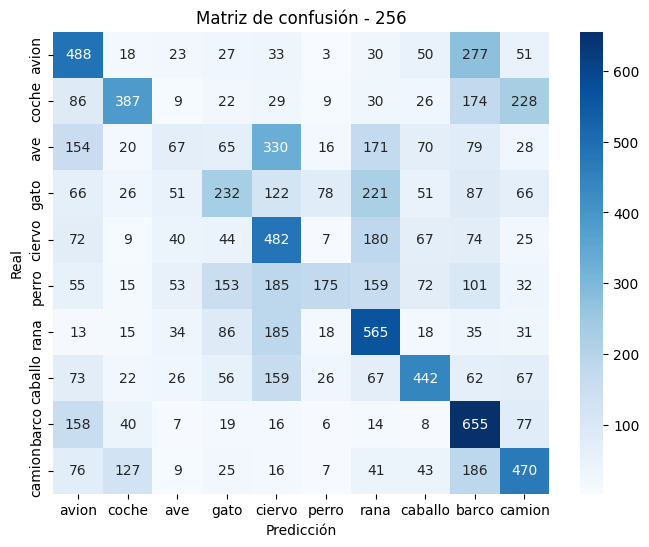


Entrenando MLP con arquitectura: [512, 128]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.1887 - loss: 2.2204 - val_accuracy: 0.3177 - val_loss: 1.8805
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2785 - loss: 1.9612 - val_accuracy: 0.3447 - val_loss: 1.8462
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3039 - loss: 1.8891 - val_accuracy: 0.3391 - val_loss: 1.8336
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3159 - loss: 1.8704 - val_accuracy: 0.3643 - val_loss: 1.7996
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3246 - loss: 1.8399 - val_accuracy: 0.3682 - val_loss: 1.7764
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3291 - loss: 1.8299 - val_accuracy: 0.3708 - val_loss: 1.7932
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3386 - loss: 1.8218 - val_accuracy: 0.3654 - val_loss: 1.7612
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accur

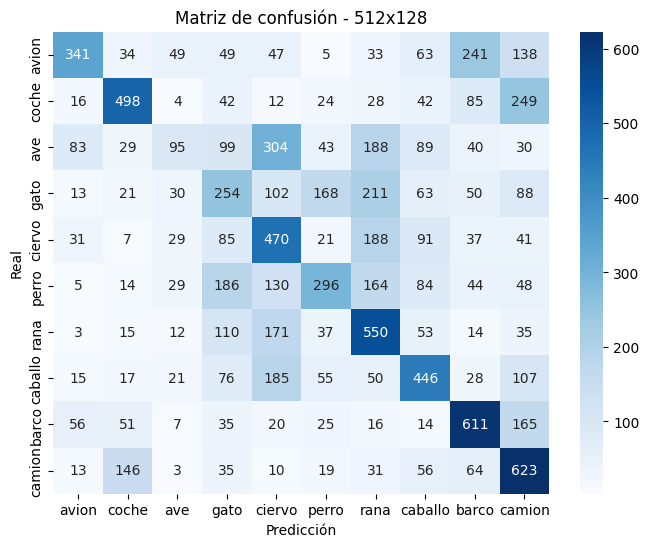


Entrenando MLP con arquitectura: [1024, 512, 128]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.1745 - loss: 2.2531 - val_accuracy: 0.2843 - val_loss: 1.9599
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2808 - loss: 1.9654 - val_accuracy: 0.3463 - val_loss: 1.8420
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3053 - loss: 1.9035 - val_accuracy: 0.3546 - val_loss: 1.7988
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3104 - loss: 1.8693 - val_accuracy: 0.3614 - val_loss: 1.7804
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3228 - loss: 1.8494 - val_accuracy: 0.3648 - val_loss: 1.7851
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3343 - loss: 1.8282 - val_accuracy: 0.3773 - val_loss: 1.7513
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3387 - loss: 1.8130 - val_accuracy: 0.3904 - val_loss: 1.7395
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step -

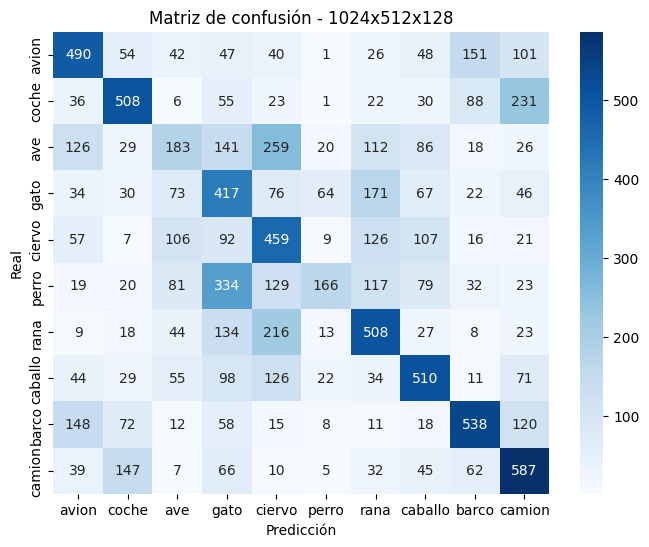

In [10]:
results = []

for config in model_configs:
    model_name = 'x'.join(map(str, config))
    print(f"\nEntrenando MLP con arquitectura: {config}")

    model = Sequential()
    model.add(Input(shape=(x_train_flat.shape[1],)))

    for units in config:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_flat, y_train_one_hot,
                        validation_data=(x_valid_flat, y_valid_one_hot),
                        epochs=20, batch_size=64, verbose=1)

    # Evaluación
    y_pred_probs = model.predict(x_test_flat)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Calcular accuracy global en test
    test_accuracy = accuracy_score(y_true, y_pred)

    # Reporte de métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]

    # Guardar resultados
    results.append((model_name, class_metrics, test_accuracy))

    # Matriz de confusión
    print(f"\nMatriz de confusión para modelo {config}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


In [11]:
for name, metrics_df, acc in results:
    print(f"\n=== Modelo {name} ===")
    print(f"Accuracy global en test: {acc*100:.2f}%")
    print(metrics_df.round(3).to_string())


=== Modelo 256 ===
Accuracy global en test: 39.63%
         precision  recall
avion        0.393   0.488
coche        0.570   0.387
ave          0.210   0.067
gato         0.318   0.232
ciervo       0.310   0.482
perro        0.507   0.175
rana         0.382   0.565
caballo      0.522   0.442
barco        0.379   0.655
camion       0.437   0.470

=== Modelo 512x128 ===
Accuracy global en test: 41.84%
         precision  recall
avion        0.592   0.341
coche        0.599   0.498
ave          0.341   0.095
gato         0.262   0.254
ciervo       0.324   0.470
perro        0.427   0.296
rana         0.377   0.550
caballo      0.446   0.446
barco        0.503   0.611
camion       0.409   0.623

=== Modelo 1024x512x128 ===
Accuracy global en test: 43.66%
         precision  recall
avion        0.489   0.490
coche        0.556   0.508
ave          0.300   0.183
gato         0.289   0.417
ciervo       0.339   0.459
perro        0.537   0.166
rana         0.438   0.508
caballo      0.501   

Como podemos ver hay accuraccy que ronda el 40%, por lo que podemos decir que los modelos son muy malos. Podemos ver que aumentar la profundidad y el número de neuronas por en las capas mejora el modelo un poco. Vamos a realizar unas pruebas con redes convolucionales.

### Redes convolucionales

In [12]:
cnn_configs = {
    'CNN_1conv': 1,
    'CNN_2conv': 2,
    'CNN_3conv': 3,
    'CNN_4conv': 4
}


Entrenando modelo: CNN_1conv

Resumen del modelo CNN_1conv:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,018 (4.01 MB)

 Trainable params: 1,050,954 (4.01 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3022 - loss: 2.0172 - val_accuracy: 0.4926 - val_loss: 1.4523
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4664 - loss: 1.4752 - val_accuracy: 0.5540 - val_loss: 1.2484
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5312 - loss: 1.3046 - val_accuracy: 0.5559 - val_loss: 1.2588
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5642 - loss: 1.2049 - val_accuracy: 0.5645 - val_loss: 1.2320
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5974 - loss: 1.1117 - val_accuracy: 0.6004 - val_loss: 1.1430
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6187 - loss: 1.0505 - val_accuracy: 0.5867 - val_loss: 1.2126
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6483 - loss: 0.9769 - val_accuracy: 0.6213 - val_loss: 1.1112
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6688 - loss: 0.9282 - val_accuracy: 0.

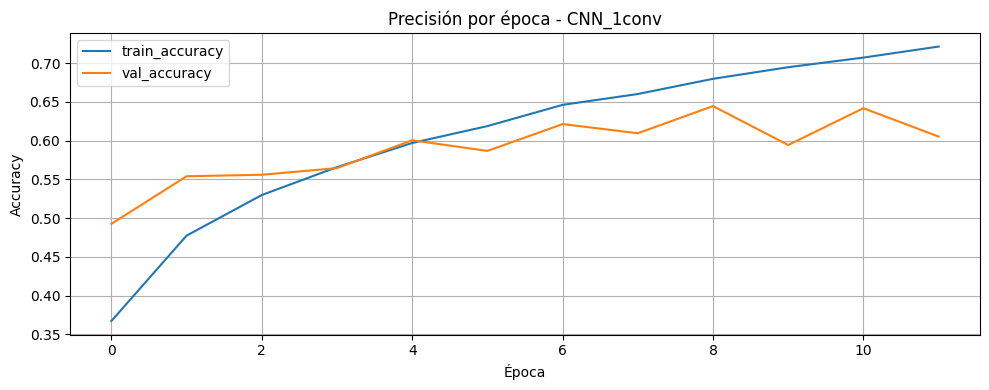

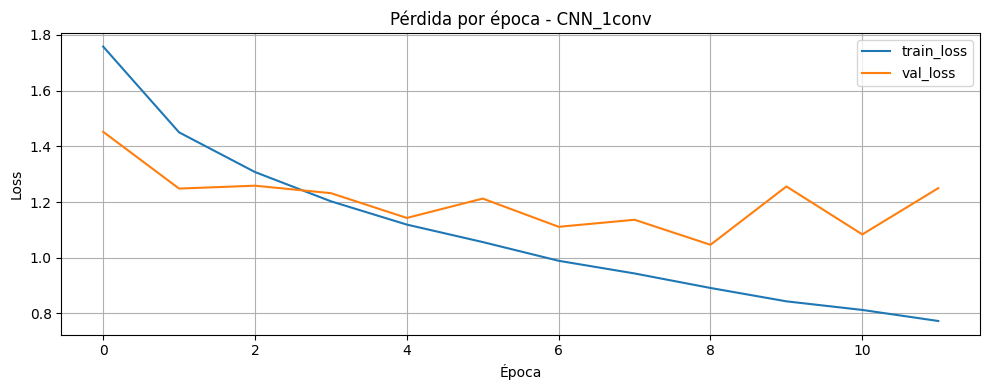

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Matriz de confusión para CNN_1conv


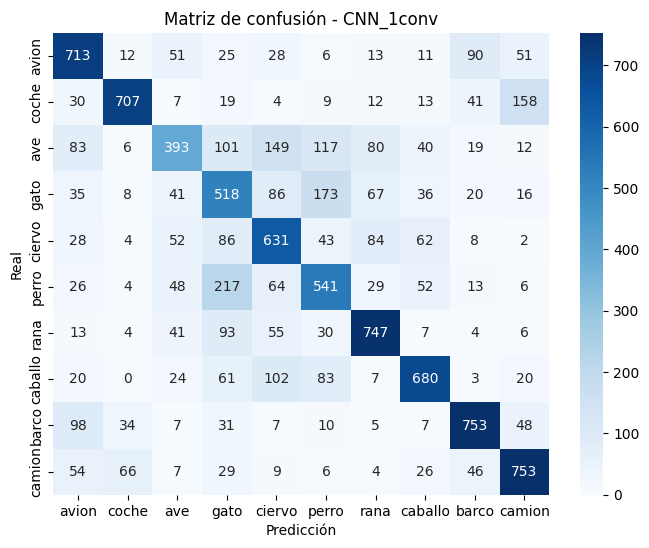


Entrenando modelo: CNN_2conv

Resumen del modelo CNN_2conv:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3038 - loss: 2.0024 - val_accuracy: 0.4504 - val_loss: 1.4994
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4646 - loss: 1.4693 - val_accuracy: 0.5473 - val_loss: 1.2879
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5281 - loss: 1.2975 - val_accuracy: 0.6015 - val_loss: 1.1086
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5809 - loss: 1.1730 - val_accuracy: 0.6160 - val_loss: 1.0633
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6103 - loss: 1.0968 - val_accuracy: 0.6545 - val_loss: 0.9868
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6416 - loss: 1.0125 - val_accuracy: 0.6630 - val_loss: 0.9661
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6612 - loss: 0.9603 - val_accuracy: 0.6811 - val_loss: 0.9280
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6775 - loss: 0.9076 - val_accuracy: 0.

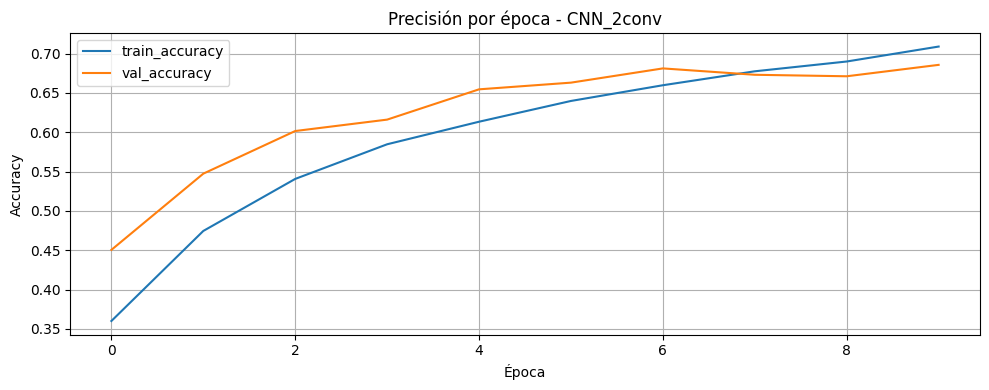

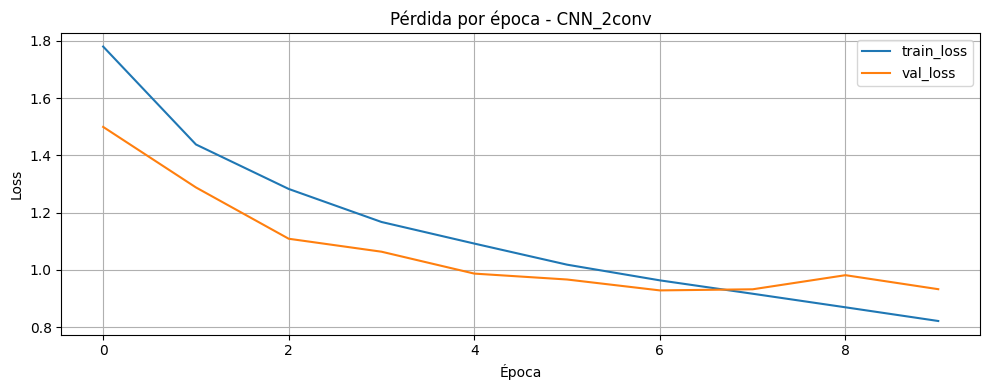

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Matriz de confusión para CNN_2conv


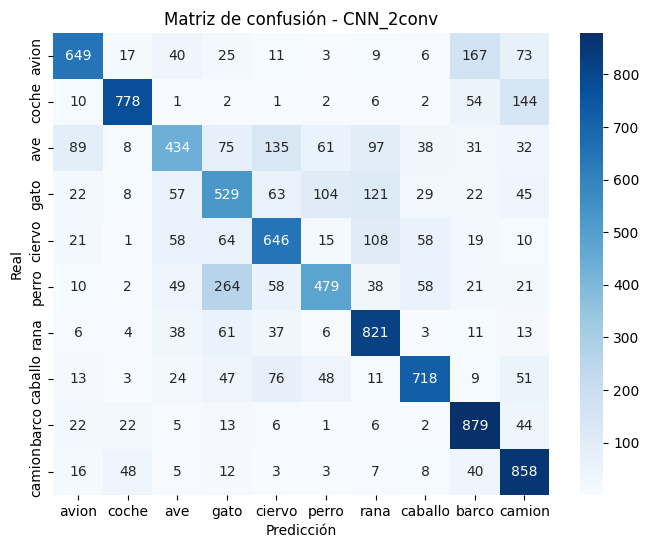


Entrenando modelo: CNN_3conv

Resumen del modelo CNN_3conv:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3224 - loss: 1.9190 - val_accuracy: 0.5039 - val_loss: 1.3855
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5079 - loss: 1.3734 - val_accuracy: 0.4755 - val_loss: 1.5682
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5847 - loss: 1.1694 - val_accuracy: 0.6309 - val_loss: 1.0649
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6366 - loss: 1.0365 - val_accuracy: 0.6554 - val_loss: 0.9802
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6833 - loss: 0.9138 - val_accuracy: 0.6175 - val_loss: 1.1184
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7098 - loss: 0.8234 - val_accuracy: 0.5699 - val_loss: 1.2232
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7318 - loss: 0.7625 - val_accuracy: 0.6566 - val_loss: 0.9835


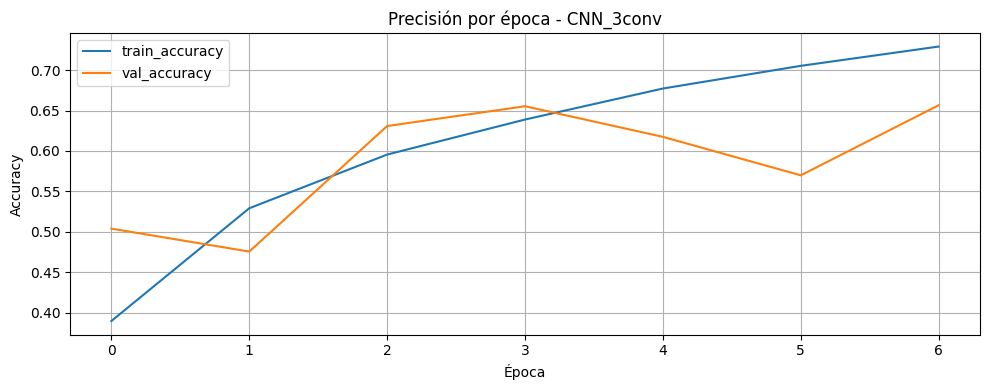

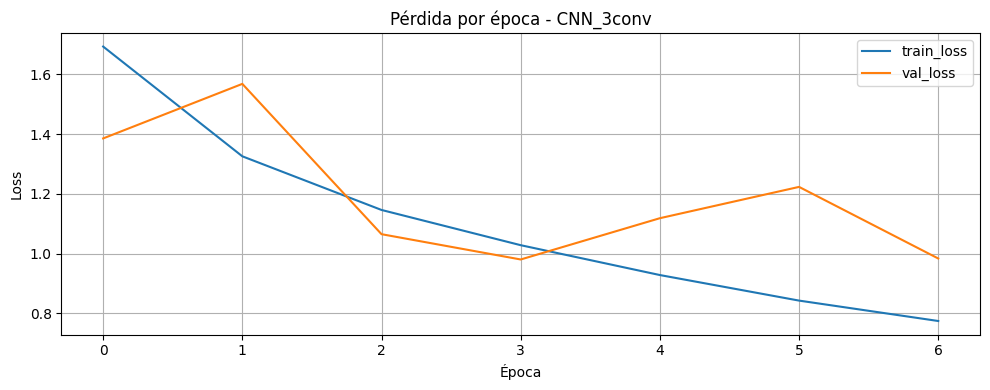

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Matriz de confusión para CNN_3conv


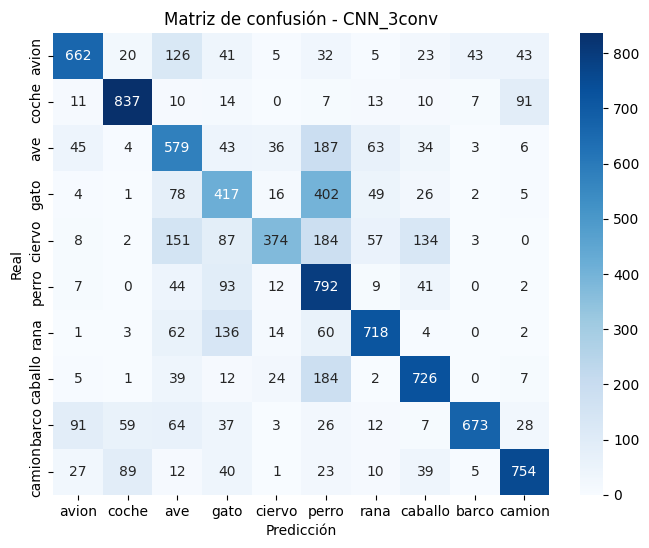


Entrenando modelo: CNN_4conv

Resumen del modelo CNN_4conv:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,826 (1.99 MB)

 Trainable params: 521,866 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3382 - loss: 1.8754 - val_accuracy: 0.4642 - val_loss: 1.4474
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5349 - loss: 1.3004 - val_accuracy: 0.5524 - val_loss: 1.3011
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6258 - loss: 1.0720 - val_accuracy: 0.6451 - val_loss: 1.0178
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6878 - loss: 0.9043 - val_accuracy: 0.7046 - val_loss: 0.8481
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7325 - loss: 0.7727 - val_accuracy: 0.6741 - val_loss: 0.9686
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7614 - loss: 0.6899 - val_accuracy: 0.6495 - val_loss: 1.1310
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7949 - loss: 0.5960 - val_accuracy: 0.7388 - val_loss: 0.8085
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8171 - loss: 0.5296 - val_accuracy: 0

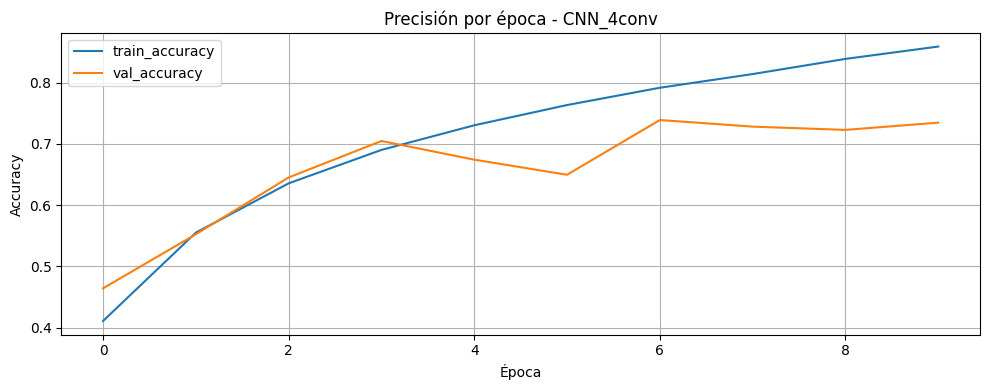

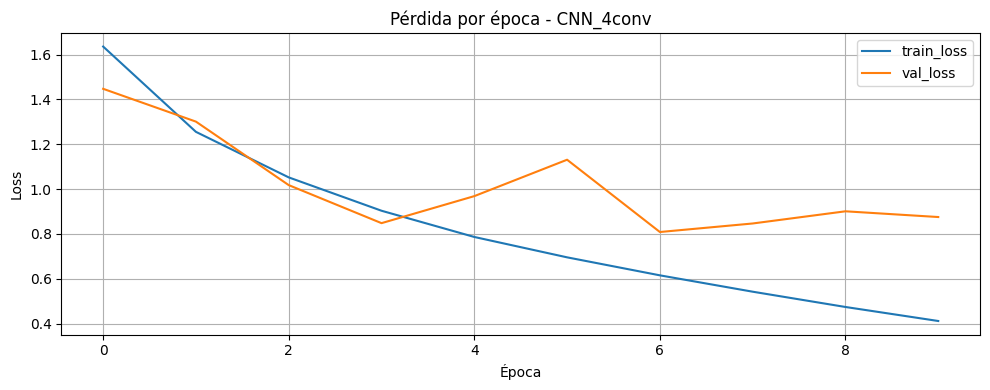

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Matriz de confusión para CNN_4conv


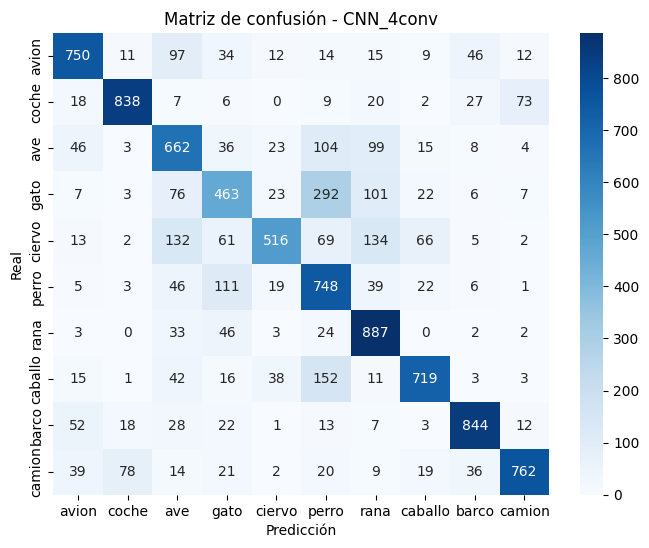

In [13]:
results = []

for name, num_convs in cnn_configs.items():
    print(f"\nEntrenando modelo: {name}")

    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))

    filters = 32
    for i in range(num_convs):
        model.add(Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(pool_size=(2, 2)))
        filters *= 2  # Duplicar filtros cada capa

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print(f"\nResumen del modelo {name}:")
    model.summary()

    # Early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(x_train, y_train_one_hot,
                        validation_data=(x_valid, y_valid_one_hot),
                        epochs=30,
                        batch_size=64,
                        callbacks=[early_stop],
                        verbose=1)

    # Graficar precisión
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(f'Precisión por época - {name}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graficar pérdida
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'Pérdida por época - {name}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    # Evaluación
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Accuracy
    test_acc = accuracy_score(y_true, y_pred)

    # Métricas por clase
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]

    results.append((name, class_metrics, test_acc))

    # Matriz de confusión
    print(f"\nMatriz de confusión para {name}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()


In [14]:
for name, metrics_df, acc in results:
    print(f"\n=== Modelo {name} ===")
    print(f"Accuracy global en test: {acc*100:.2f}%")
    print(metrics_df.round(3).to_string())



=== Modelo CNN_1conv ===
Accuracy global en test: 64.36%
         precision  recall
avion        0.648   0.713
coche        0.837   0.707
ave          0.586   0.393
gato         0.439   0.518
ciervo       0.556   0.631
perro        0.531   0.541
rana         0.713   0.747
caballo      0.728   0.680
barco        0.755   0.753
camion       0.702   0.753

=== Modelo CNN_2conv ===
Accuracy global en test: 67.91%
         precision  recall
avion        0.756   0.649
coche        0.873   0.778
ave          0.610   0.434
gato         0.484   0.529
ciervo       0.624   0.646
perro        0.663   0.479
rana         0.671   0.821
caballo      0.779   0.718
barco        0.702   0.879
camion       0.665   0.858

=== Modelo CNN_3conv ===
Accuracy global en test: 65.32%
         precision  recall
avion        0.769   0.662
coche        0.824   0.837
ave          0.497   0.579
gato         0.453   0.417
ciervo       0.771   0.374
perro        0.418   0.792
rana         0.765   0.718
caballo      0.6

Ahora quiero probar una arquitectura muy conocida como es alexnet, con la cual espero tener mejores resultados

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,266 (14.95 MB)

 Trainable params: 3,918,346 (14.95 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.2768 - loss: 2.2608 - val_accuracy: 0.3069 - val_loss: 1.7985
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.4920 - loss: 1.4283 - val_accuracy: 0.6201 - val_loss: 1.1543
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6121 - loss: 1.1233 - val_accuracy: 0.5569 - val_loss: 1.2446
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6769 - loss: 0.9537 - val_accuracy: 0.6826 - val_loss: 1.0512
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7275 - loss: 0.8142 - val_accuracy: 0.6031 - val_loss: 1.2043
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7627 - loss: 0.7163 - val_accuracy: 0.6550 - val_loss: 1.0475
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8006 - loss: 0.6166 - val_accuracy: 0.6640 - val_loss: 0.9866
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8321 - loss: 0.5277 - 

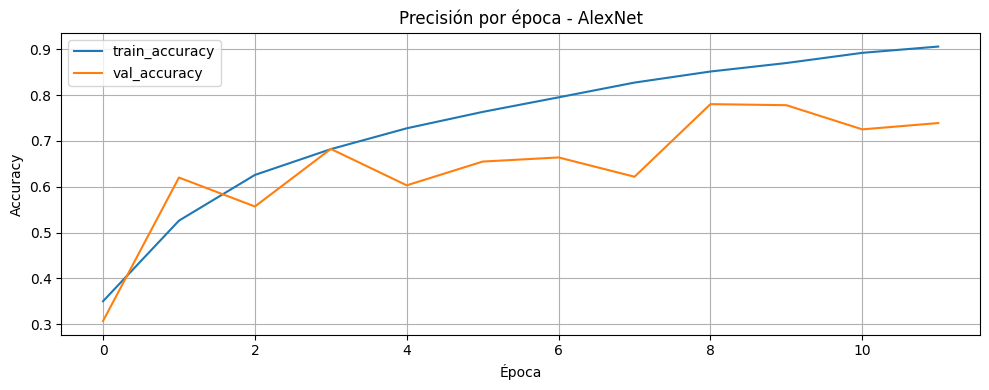

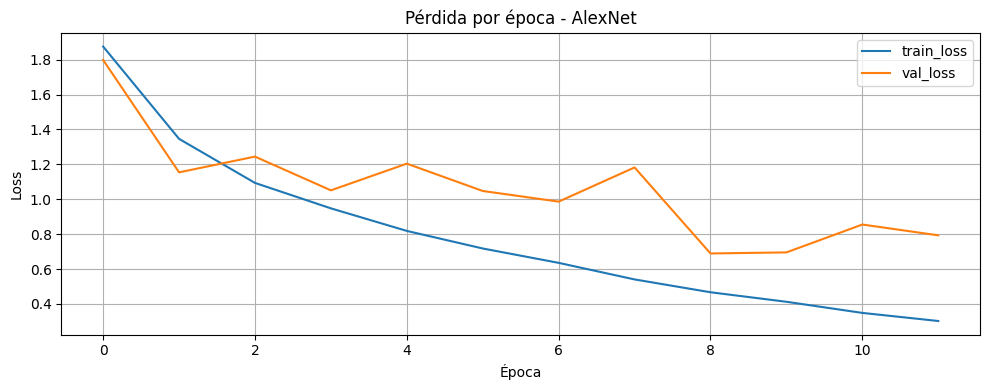

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Accuracy en test: 77.50%

=== Métricas por clase (AlexNet) ===
         precision  recall
avion        0.805   0.795
coche        0.950   0.798
ave          0.721   0.673
gato         0.578   0.611
ciervo       0.774   0.737
perro        0.664   0.730
rana         0.846   0.832
caballo      0.844   0.790
barco        0.883   0.866
camion       0.746   0.918


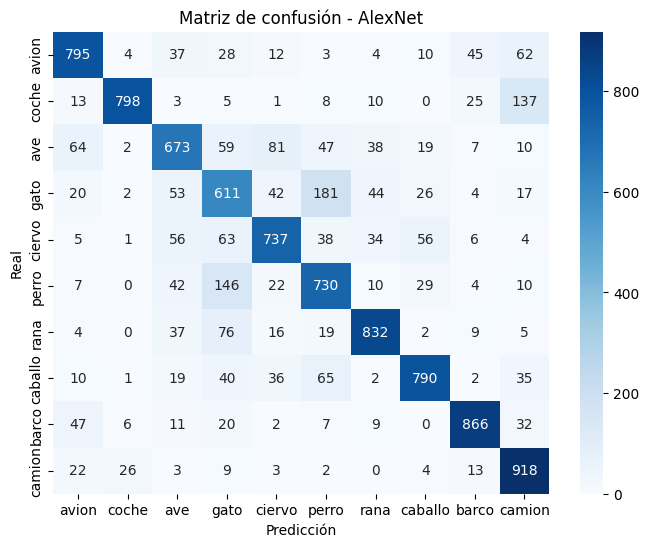

In [26]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# AlexNet adaptado
alexnet = Sequential()

alexnet.add(Input(shape=(32, 32, 3)))

# 1ª capa conv: 64 filtros 3x3
alexnet.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# 2ª capa conv: 128 filtros 3x3
alexnet.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# 3ª, 4ª, 5ª capas conv: 256 filtros
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
alexnet.add(BatchNormalization())
alexnet.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten + fully connected
alexnet.add(Flatten())
alexnet.add(Dense(512, activation='relu'))
alexnet.add(Dropout(0.5))
alexnet.add(Dense(512, activation='relu'))
alexnet.add(Dropout(0.5))

# Salida
alexnet.add(Dense(10, activation='softmax'))

# Compilar
alexnet.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Mostrar arquitectura
alexnet.summary()

# Entrenamiento con EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = alexnet.fit(x_train, y_train_one_hot,
                      validation_data=(x_valid, y_valid_one_hot),
                      epochs=30,
                      batch_size=64,
                      callbacks=[early_stop],
                      verbose=1)

# Graficar evolución
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Precisión por época - AlexNet')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Pérdida por época - AlexNet')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluación final
y_pred_probs = alexnet.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_one_hot, axis=1)

test_acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy en test: {test_acc * 100:.2f}%")

# Métricas por clase
report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.loc[:'9'][['precision', 'recall']]
df_report.index = [MAP_ELEMENTS[int(i)] for i in df_report.index]

print("\n=== Métricas por clase (AlexNet) ===")
print(df_report.round(3).to_string())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=MAP_ELEMENTS.values(),
            yticklabels=MAP_ELEMENTS.values())
plt.title('Matriz de confusión - AlexNet')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


### Comparación de resultados

Como podemos ver en la siguiente tabla, los resultados de las distintas redes convolucionales son bastante mejores que las de los perceptrones multicapa.

| Modelo                  | Accuracy Test |
| ----------------------- | ------------- |
| **MLP \[256]**          | 39.63%        |
| **MLP \[512,128]**      | 41.84%        |
| **MLP \[1024,512,128]** | 43.66%        |
| **CNN 1 capa**          | 64.36%        |
| **CNN 2 capas**         | 67.91%        |
| **CNN 3 capas**         | 65.32%        |
| **CNN 4 capas**         | 71.89%        |
| **ALEXNET**             | 77.50%        |


Esto se debe a que las CNN están especificamente diseñadas para trabajar con imágenes, a diferencia a los perceptrones multicapa, que tratan las imágenes como vectores planos.

Las CNN procesan las imágenes en 2D, manteniendo relaciones entre píxeles cercanos, lo cual es esencial para detectar bordes, texturas y formas.


#### Análisis de métricas: Precisión y recall

Primero vamos a explicar lo que son las metricas.

- Precisión: mide la calidad de las predicciones positivas. Es decir, si predecimos coches, de todas las veces que dice que es un coche, cuantas son verdad.

- Recall: mide la cobertura de las verdaderas etiquetas. Es decir, de todos los coches que había, cuantos detectó correctamente la red.

En el mejor modelo (AlexNet), las mejores clases respecto a recall y precision son avion, coche, rana, barco y camión. Esto puede ser a que son más distintivos visualmente, con formas grandes y fáciles de detectar.

Vamos a ver un resumen de las 9 primeras imágenes mal clasificadas por el mejor modelo a ver si podemos hacernos una idea de por qué se clasifican mal.

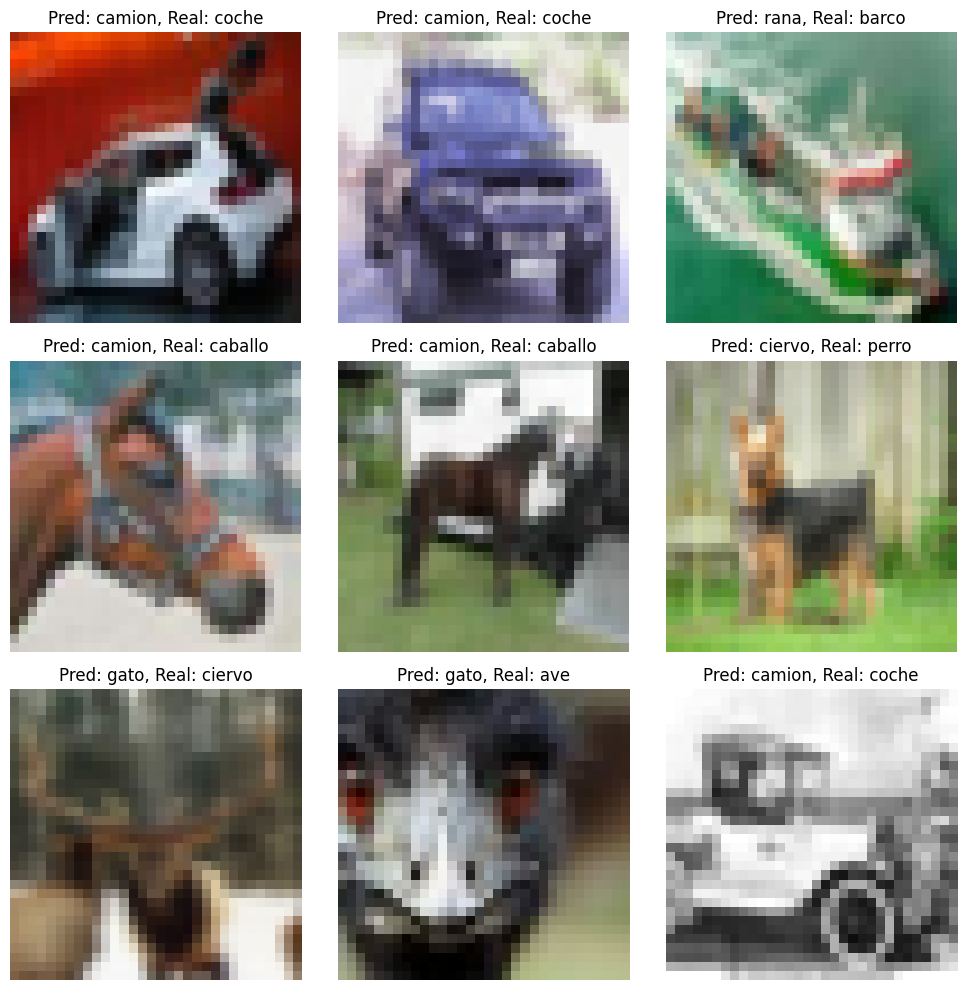

In [27]:
incorrect_idxs = np.where(y_pred != y_true)[0]
plt.figure(figsize=(10, 10))
for i, idx in enumerate(incorrect_idxs[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"Pred: {MAP_ELEMENTS[y_pred[idx]]}, Real: {MAP_ELEMENTS[y_true[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


### Preentrenados

In [16]:
import tensorflow as tf

vgg_model = tf.keras.applications.vgg16.VGG16(weights='imagenet', include_top = False ,classes = 10, input_shape=(32, 32, 3))
# ResNet = tf.keras.applications.resnet50.ResNet50()
# MobileNet = tf.keras.applications.mobilenet_v2.MobileNetV2()
# EfficientNet = tf.keras.applications.efficientnet.EfficientNetB0()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [17]:
last = vgg_model.get_layer('block3_pool').output

In [18]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(10, activation='softmax')(x)

model = Model(vgg_model.input, x)


In [19]:
for layer in vgg_model.layers:
    layer.trainable = False

#compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
model.summary()

Model: "functional_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,836,490 (7.01 MB)

 Trainable params: 100,490 (392.54 KB)

 Non-trainable params: 1,736,000 (6.62 MB)

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [22]:
history = model.fit(x_train, y_train_one_hot,
                    validation_data=(x_valid, y_valid_one_hot),
                    epochs=30,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.3651 - loss: 1.8445 - val_accuracy: 0.6305 - val_loss: 1.0748
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5673 - loss: 1.2518 - val_accuracy: 0.6673 - val_loss: 0.9682
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6052 - loss: 1.1432 - val_accuracy: 0.6802 - val_loss: 0.9178
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6293 - loss: 1.0776 - val_accuracy: 0.6938 - val_loss: 0.8769
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6441 - loss: 1.0282 - val_accuracy: 0.7032 - val_loss: 0.8657
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6527 - loss: 1.0111 - val_accuracy: 0.7086 - val_loss: 0.8398
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6646 - loss: 0.9763 - val_accuracy: 0.7087 - val_loss: 0.8326
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.6703 - loss: 0.9641 - val_accurac

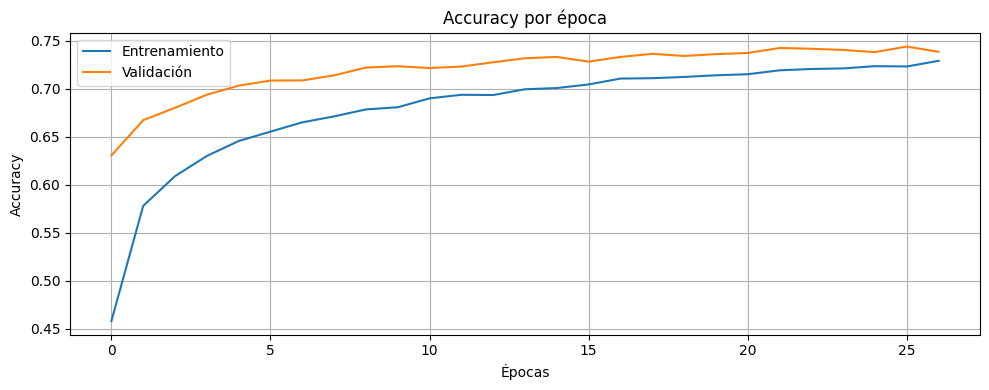

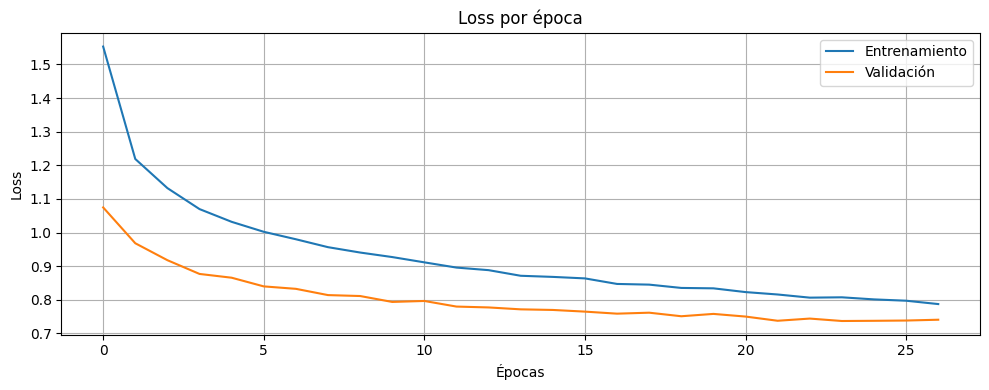

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

Accuracy global en el conjunto de test (VGG16): 73.75%

Métricas por clase en el conjunto de test (VGG16):
         precision  recall  f1-score  support
avion        0.759   0.786     0.772   1000.0
coche        0.817   0.835     0.826   1000.0
ave          0.701   0.613     0.654   1000.0
gato         0.565   0.571     0.568   1000.0
ciervo       0.664   0.708     0.685   1000.0
perro        0.712   0.580     0.639   1000.0
rana         0.744   0.819     0.780   1000.0
caballo      0.783   0.806     0.794   1000.0
barco        0.802   0.873     0.836   1000.0
camion       0.819   0.784     0.801   1000.0

Matriz de confusión en el conjunto de test (VGG16)


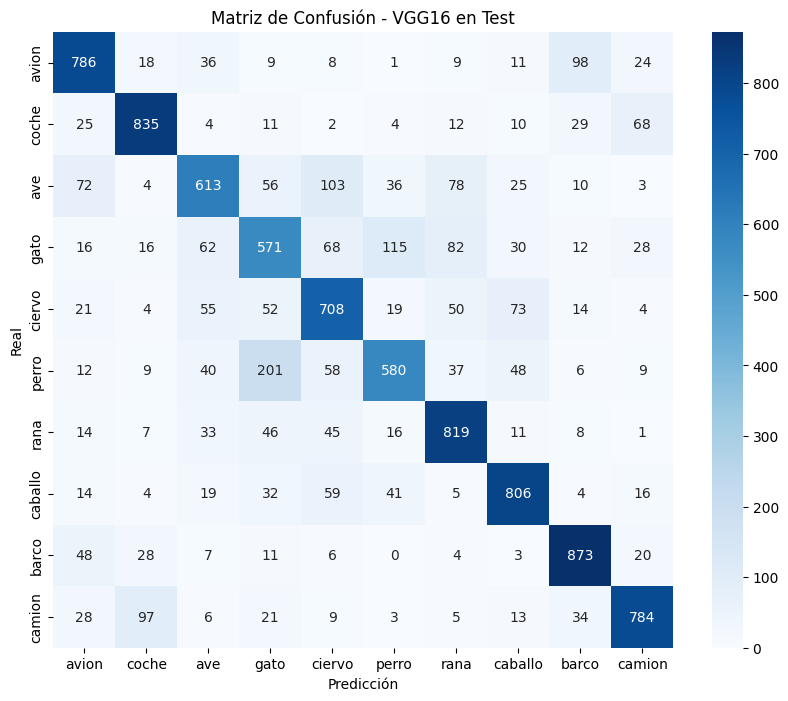

In [24]:
# Obtener predicciones desde el dataset de test
#y_pred_probs = model.predict(test_ds) # Original line
y_pred_probs_test = model.predict(x_test) # Changed line
y_pred_test = np.argmax(y_pred_probs_test, axis=1)
y_true_test = np.argmax(y_test_one_hot, axis=1)

# Calcular accuracy global en test
test_accuracy = accuracy_score(y_true_test, y_pred_test)
print(f"\nAccuracy global en el conjunto de test (VGG16): {test_accuracy*100:.2f}%")

# Reporte de métricas por clase en test
report_test = classification_report(y_true_test, y_pred_test, output_dict=True, zero_division=0)
df_report_test = pd.DataFrame(report_test).transpose()
class_metrics_test = df_report_test.loc[:'9'][['precision', 'recall', 'f1-score', 'support']]
class_metrics_test.index = [MAP_ELEMENTS[int(i)] for i in class_metrics_test.index]

print("\nMétricas por clase en el conjunto de test (VGG16):")
print(class_metrics_test.round(3).to_string())

# Matriz de confusión en test
print("\nMatriz de confusión en el conjunto de test (VGG16)")
cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=MAP_ELEMENTS.values(),
            yticklabels=MAP_ELEMENTS.values())
plt.title('Matriz de Confusión - VGG16 en Test')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

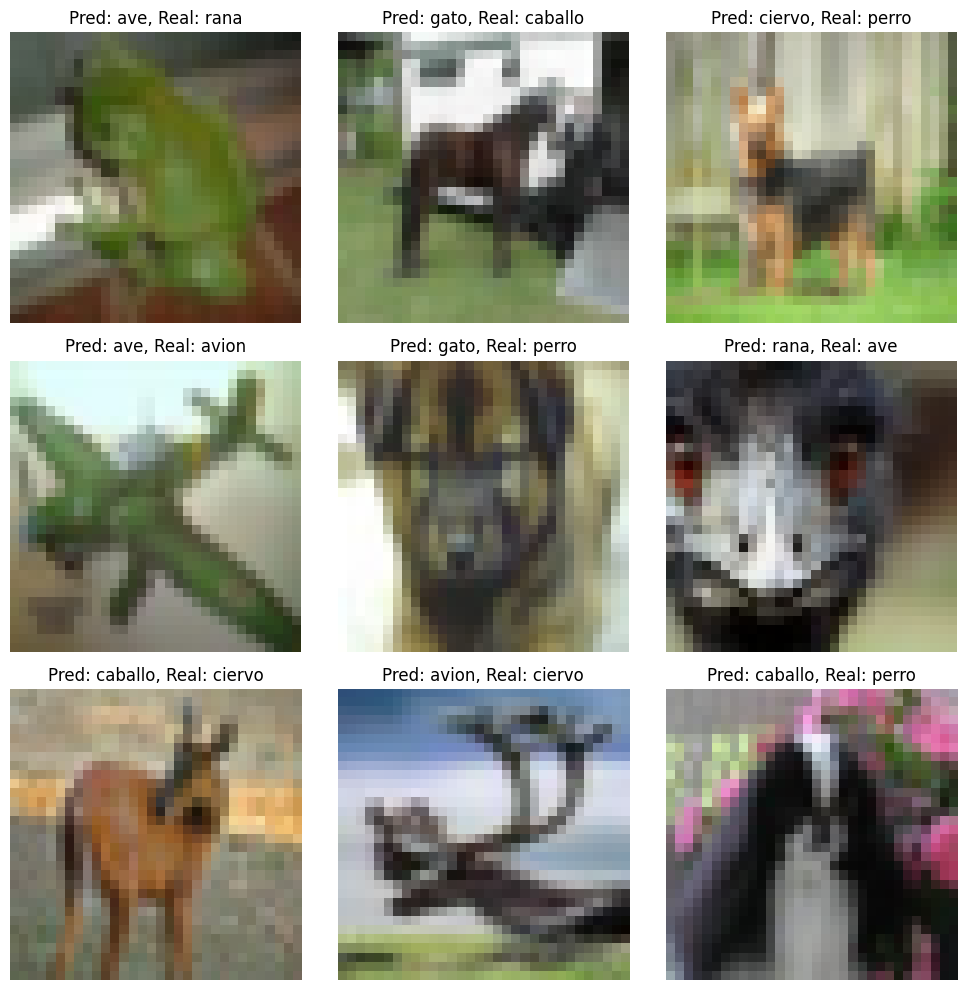

In [25]:
# Ver imágenes mal clasificadas
incorrect_idxs = np.where(y_pred_test != y_true_test)[0]
plt.figure(figsize=(10, 10))
for i, idx in enumerate(incorrect_idxs[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"Pred: {MAP_ELEMENTS[y_pred_test[idx]]}, Real: {MAP_ELEMENTS[y_true_test[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()